# Notebook 13 — Agentic RL I: From Reasoning to Acting, and Why Agents Need RL

### Course roadmap

**Part I — classical RL** (`numpy` only)
1. Foundations & MDPs · 2. Dynamic Programming · 3. Monte Carlo & TD · 4. Function Approximation & DQN · 5. Policy Gradients · 6. Trust Regions & PPO

**Part II — RL for language models**
7. RLHF · 8. RLOO & RLVR · 9. GRPO & DeepSeek-R1 · 10. DPO & production libraries · 11. RLCD · 12 / 12.2 / 12.3. Teaching a small model to reason (GRPO, RLCD, PPO)

**Part III — Agentic RL**
- **13. Agentic RL foundations: from reasoning to acting, and why agents need RL** ← *you are here*
- 14. The agent loop as an RL environment: multi-turn rollouts, tool calls, observation masking
- 15. Credit assignment across turns: trajectory vs step-level advantages, critics, process rewards
- 16. A real tool-using agent: Qwen2.5-0.5B + calculator, multi-turn GRPO in PyTorch and `trl`
- 17. Agentic RL at scale: reward hacking, async/off-policy rollouts, frameworks, open problems

Like Part I, this notebook needs **only `numpy` and `matplotlib`**.

### Where we are

Notebooks 8–12 trained language models in the **bandit** setting:
one prompt → one completion → one reward. Notebook 12 made
`Qwen2.5-0.5B-Instruct` *think before answering*, but the model was
still alone with its thoughts. Nothing outside the model ever answered back.

An **agent** is different. It *acts*: it calls a search engine, runs code, clicks
a button, edits a file. Then it **reads what the world sent back** and decides
what to do next. That loop is the topic of Part III.

### What this notebook covers

1. What an LLM agent is, and what changes when a reasoning model becomes an agent.
2. **A topic map of Agentic RL**: every idea the series uses, and where each one appears.
3. **How we got here**: prompting → imitation → RL, and *why* the field moved to RL.
4. **The formalism**: agents as POMDPs, and why the policy gradient ignores
   tokens the environment wrote (the reason for "observation masking").
5. **An experiment** that shows the core argument for RL in miniature:
   behavior cloning breaks down as the horizon grows, DAgger fixes it with
   expensive expert labels, and RL fixes it with only an outcome reward.
   Prior knowledge from SFT makes RL possible, and a curriculum makes it
   reach long horizons.
6. The anatomy of a real agent trajectory: a preview of notebook 14.

## 1. What is an LLM agent?

An **LLM agent** is a language model used as a **policy inside a loop**:

```
             ┌──────────────────────────────────────────────┐
             │                 environment                  │
             │  (search engine, Python sandbox, repo + test │
             │   suite, browser, database, a human user...) │
             └──────────────▲──────────────────┬────────────┘
                 action a_t │                  │ observation o_t
        (tool call, code,   │                  │ (search results, stdout,
         click, message)    │                  ▼  error message, test log)
             ┌──────────────┴──────────────────────────────┐
             │   LLM policy  π_θ(a_t | h_t)                │
             │   h_t = task + a_1 o_1 a_2 o_2 ... o_{t-1}  │  ← the context window is the state
             └─────────────────────────────────────────────┘
```

The loop runs until the model gives a final answer, the task is solved, or a
turn or token budget runs out. Common kinds of agents:

| agent | actions | observations | how success is checked |
|---|---|---|---|
| tool-calling assistant | JSON function calls (`calculator`, `get_weather`, a CRM API) | function results | the final answer, or the final database state (e.g. τ-bench) |
| search / deep-research agent | `search(query)`, `open(url)` | snippets, pages | answer correctness (exact match, or a judge) |
| coding / SWE agent | shell commands, file edits | stdout, compiler errors, test logs | the hidden test suite passes |
| web / GUI / computer-use agent | click, type, scroll | screenshots, DOM / accessibility tree | the task's end state (order placed, form filled) |
| game / puzzle agent | moves | board state | win / lose |

### What changes compared with notebooks 8–12

| | reasoning RL (notebooks 8–12) | agentic RL (this part) |
|---|---|---|
| episode | 1 turn: prompt → completion | **many turns**: act → observe → act → … |
| who writes the tokens | the model writes every completion token | the model writes **actions**; the **environment** writes observations into the same context |
| transitions | deterministic: "append the token" | **stochastic and external**: a search engine, a flaky API, a test runner |
| state | the prompt plus tokens so far | the whole interaction history (often much longer than the model's own output) |
| reward | one score at the end | usually still one score at the end, but after **many decisions** → harder credit assignment |
| cost of a rollout | one `generate` call | many `generate` calls **plus** tool execution (seconds to minutes) |
| what can go wrong | verifier hacking, length bias | all of that, **plus** compounding errors, unrecoverable states, tool misuse, environment hacking (e.g. editing the tests) |

The policy-gradient machinery (REINFORCE, baselines, PPO-clip, GRPO groups, KL
penalties) carries over **unchanged**. What's new is the *environment*, the
*horizon*, and the fact that part of the context wasn't written by the
policy.

## 2. The Agentic RL topic map

Here are the topics this part of the course covers, grouped by the question each
one answers. The last column says where it's covered.

| area | topic | the question it answers | notebook |
|---|---|---|---|
| **Why** | imitation vs RL; compounding errors; DAgger | why not just fine-tune on expert trajectories? | **13** |
| | priors & exploration | why does agentic RL start from an SFT / instruct model? | **13**, 16 |
| **Formalism** | POMDP; token-level vs turn-level MDP | what are the state, action and reward of an LLM agent? | **13**, 15 |
| | trajectory log-likelihood | which tokens does the policy gradient touch? | **13**, 14 |
| **Rollouts** | environment API (`reset` / `step`), tool-call parsing, the multi-turn loop | how do we generate training data from an agent? | **14**, 16 |
| | observation (loss) masking | why must tool-output tokens be excluded from the loss? | **14**, 16 |
| | turn budgets, truncation, malformed calls | what happens when an episode doesn't finish cleanly? | **14** |
| **Rewards** | outcome, format and tool-cost rewards | what exactly do we reward, and what does that teach? | **14**, 16 |
| | process rewards, reward shaping (potential-based vs naive) | can we reward intermediate steps without being gamed? | **15** |
| | LLM-as-judge and rubric rewards | what if the outcome can't be checked by a program? | 17 (and 12.2's RLCD) |
| **Credit assignment** | trajectory-level GRPO, step-level grouping (GiGPO), turn-level critic + GAE, discounting | which of the 10 actions made the episode succeed? | **15** |
| **Practice** | multi-turn GRPO on a real SLM with tools; `trl`'s `tools` / `environment_factory` | how does this look with a real model? | **16** |
| **Failure modes** | reward hacking in environments (e.g. editing the tests) | what do agents exploit, and how do we defend? | **17** |
| | entropy collapse, "echo trap", zero-variance groups | why does multi-turn RL become unstable? | 14, 15, **17** |
| **Systems** | async rollouts, policy staleness, off-policy correction (truncated IS), train/inference mismatch | how do we train when episodes take minutes? | **17** |
| | context / memory management | what if the history no longer fits in the context? | 17 |
| | frameworks: `trl`, verl, OpenRLHF, SkyRL, rLLM, AReaL, ART, … | which tools do people use in practice? | 17 |
| **Evaluation** | pass@k, success rate, cost per success; benchmarks (SWE-bench, WebArena, τ-bench, GAIA, BrowseComp, OSWorld) | how do we know the agent got better? | 16, 17 |

## 3. How we got here: prompting → imitation → RL

### Era 1 — prompting (2022–2023): agents without training

- **ReAct** (Yao et al., 2022) interleaved *reasoning* ("Thought: …") with
  *acting* ("Action: search[…]") in a few-shot prompt. This is the template
  almost every agent still uses.
- **Reflexion** (Shinn et al., 2023) let an agent write a verbal
  self-critique after a failure and keep it in memory for the next attempt:
  "reinforcement learning" in the prompt, with **no weight updates**.

These methods work, but only as well as the frozen model's in-context ability.
They're brittle on long tasks, and they don't make the model *better*.

### Era 2 — imitation (2021–2024): fine-tune on trajectories

- **WebGPT** (Nakano et al., 2021) taught GPT-3 to browse by **behavior
  cloning** on human demonstrations, then improved it with a reward model
  (rejection sampling and RL), the RLHF recipe of notebook 7 applied to an
  agent.
- **Toolformer** (Schick et al., 2023) let the model annotate its own text with
  API calls, and kept the calls that helped predict the next tokens.
- **FireAct**, **AgentTuning** (2023) and many others: collect trajectories
  from a strong model (often GPT-4), keep the successful ones, and **SFT** a
  smaller model on them.

Imitation teaches the *format* of tool use quickly and cheaply. Three
limitations push the field towards RL:

1. **Compounding errors.** A cloned policy makes small mistakes, and each
   mistake takes it to states the demonstrations never visited, where it makes
   *more* mistakes. Ross & Bagnell (2010) showed the expected number of errors of
   behavior cloning can grow like $O(\varepsilon T^2)$ over a horizon $T$,
   versus $O(\varepsilon T)$ for a learner trained on its *own* state distribution.
2. **No recovery data.** Experts rarely fail, and "keep only successful
   trajectories" removes the failures that do happen. So the student never sees
   an error message followed by a good recovery.
3. **A ceiling.** A clone is at best as good as the teacher, including the
   teacher's bad habits.

### Era 3 — RL (2024 →): learn from the environment's outcome

- **Multi-turn RL for agents** appeared first in research: ArCHer
  (hierarchical, turn-level critic, 2024), DigiRL (Android device control,
  2024), WebRL (web agents with a self-evolving curriculum, 2024).
- **DeepSeek-R1** (January 2025, notebook 9) showed that **RL with
  verifiable rewards** works at scale for reasoning. The same recipe was then
  extended from "think, then answer" to "think, **act**, observe, think, …":
  - **Search-R1**, **ReSearch**, **R1-Searcher** (2025): GRPO/PPO with a search
    engine in the loop, outcome reward = exact match, **retrieved tokens masked
    out of the loss**.
  - **ReTool** (2025): RL with a code interpreter for math.
  - **RAGEN / StarPO** (2025): multi-turn RL on games and puzzles, and the
    "echo trap" instability (notebook 17).
  - **SWE-RL**, **DeepSWE** (2025): RL for software-engineering agents with
    test-based rewards.
- Industry followed. OpenAI described **deep research** as trained with
  end-to-end RL on browsing and reasoning tasks, and said **o3 / o4-mini** were
  trained to use tools through RL. Several labs reported "agentic RL" stages
  for their open models (for example Moonshot's Kimi-Researcher and Kimi K2,
  and Zhipu's GLM-4.5).
- Libraries made it routine: `trl`'s `GRPOTrainer` now accepts `tools=` and an
  `environment_factory=` (notebook 16), and dedicated frameworks (verl, SkyRL,
  rLLM, AReaL, ART, …) focus on multi-turn agents (notebook 17).

### So why is RL the choice? Five reasons, one caveat

| reason | what it means | where we test it |
|---|---|---|
| **1. On-policy data** | RL trains on the states the *agent itself* reaches, including its own mistakes, so there's no train/test distribution shift. | Section 5 (BC vs RL vs horizon) |
| **2. Recovery is learned** | Errors, timeouts and dead ends happen in training rollouts. Recovering from them is rewarded, so the agent learns it. | Section 5 |
| **3. Cheap supervision** | RL needs a **check** of the outcome (tests pass? answer right? item in the cart?), not step-by-step demonstrations. For long tasks, demonstrations are expensive and checks are cheap. | Section 5.3 |
| **4. Can exceed the teacher** | RL optimizes the outcome, not similarity to a demonstrator, so it can find better strategies (search more, verify before answering, use fewer tool calls). | notebooks 14–16 |
| **5. The environment is the teacher** | Ground truth comes from the world (a compiler, a test suite, a database), so it isn't limited by what a human can label. | notebooks 14, 16 |

**The caveat:** RL doesn't create behavior from nothing. Notebooks 8 and
12 showed that it **sharpens** what the model already samples. For a long-horizon
agent, a random policy almost never succeeds, so every group has
zero variance and nothing is learned. In practice that's why agentic RL
**starts from a capable model** (pretraining + instruction/tool SFT) and often
uses a **curriculum**. Section 5.4 shows both effects.

## 4. The formalism: an agent is a policy in a POMDP

### The agent's view

The real environment has a hidden state $s_t$: the files on disk, the web, the
database. The agent sees only **observations** $o_t$, so formally this is a
**POMDP** (partially observable MDP). The standard trick for LLM agents is to
make the **history** the state:

$$
h_t = (x,\ a_1,\ o_1,\ a_2,\ o_2,\ \dots,\ a_{t-1},\ o_{t-1}),
\qquad a_t \sim \pi_\theta(\cdot \mid h_t).
$$

$x$ is the task. The context window *is* the state. Everything the agent
knows is whatever has been written into it. (When the history no longer
fits, the agent needs memory management: notebook 17.)

### Two levels of "action"

| | token-level MDP | turn-level MDP |
|---|---|---|
| action | one token | one whole message (a tool call, or the final answer) = many tokens |
| transition | append the token; or, after an action ends, the environment appends $o_t$ | the environment executes the call and returns $o_t$ |
| horizon | thousands of steps | a handful to a few hundred turns |
| used for | the log-probabilities the loss is built from | credit assignment: "which *turn* was good?" (notebook 15) |

### Which tokens does the policy gradient touch?

The probability of a whole trajectory $\tau = (x, a_1, o_1, \dots, a_T)$ factorizes
into the agent's choices and the environment's responses:

$$
p_\theta(\tau) \;=\; p(x)\prod_{t=1}^{T} \underbrace{\pi_\theta(a_t \mid h_t)}_{\text{agent}}\;\underbrace{P(o_t \mid h_t, a_t)}_{\text{environment}} .
$$

Take the log and the gradient. The environment's terms **don't depend on $\theta$**:

$$
\nabla_\theta \log p_\theta(\tau) \;=\; \sum_{t=1}^{T} \nabla_\theta \log \pi_\theta(a_t \mid h_t)
\;=\; \sum_{t=1}^{T}\ \sum_{k \in a_t} \nabla_\theta \log \pi_\theta(y_k \mid y_{<k}) .
$$

So the REINFORCE / GRPO gradient

$$
\nabla_\theta J = \mathbb{E}_\tau\Big[\hat A(\tau)\ \nabla_\theta \log p_\theta(\tau)\Big]
$$

sums over **the tokens the agent generated, and only those**. The
observation tokens are *conditioning*: the model reads them, but it didn't
choose them. In code, every trajectory carries a mask that is 1 on agent tokens
and 0 on prompt and observation tokens. This is **observation masking** (also
called loss masking or `env_mask`). Getting it wrong is one of the most common
bugs in agentic RL. Notebook 14 shows what happens if you forget it.

The full objective is the familiar one from notebooks 9 and 12, with the
KL penalty also restricted to agent tokens:

$$
\max_\theta\ \mathbb{E}_{x,\ \tau \sim \pi_\theta}\big[R(\tau)\big] \;-\; \beta\, \mathbb{E}\Big[\textstyle\sum_{k\,\in\,\text{agent tokens}} \mathrm{KL}_k\big(\pi_\theta \,\Vert\, \pi_{\text{ref}}\big)\Big].
$$

## 5. Experiment: why imitation breaks on long horizons, and RL doesn't

### The toy: a tool chain with flaky tools

A task is a sequence of $T$ sub-goals $g_1, \dots, g_T$, each one of $K = 6$ tools
to call (think "search, open, extract, compute, write, submit"). At each step
the agent observes **(the pending sub-goal, the status of the last call)** and
picks one of $K + 2$ actions: one of the 6 tools, `RETRY` or `FIX_ARGS`.

- Status `OK`: calling the right tool works... **except that tools are flaky**.
  With probability $p_{\text{fail}} = 0.15$ the call returns an error,
  `TIMEOUT` or `BAD_ARGS`, and the sub-goal stays pending.
- After `TIMEOUT` the right move is `RETRY`; after `BAD_ARGS` it's `FIX_ARGS`.
  Either returns the status to `OK`, and the tool must be called again.
- **Any wrong action silently corrupts the task**: it continues, but can no
  longer succeed. (A real agent that ignores an error message and carries on
  is the everyday version of this.)
- Reward: **1 if all $T$ sub-goals finish uncorrupted** within $3T$ steps,
  else 0. Only the outcome is rewarded; nothing is given per step.

The **expert** knows the right action in every state. But its demonstrations
were recorded in a sandbox where **tools never fail**, so the demonstrations
contain no error states. That's a stylized version of real demonstration data:
recorded on the happy path, or filtered down to clean successful runs.

The **policy** is a linear softmax over features
[one-hot(sub-goal), one-hot(status), bias], small enough to train in
seconds with the numpy code from Part I.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

class Adam:                                    # same optimizer as notebooks 4-9
    def __init__(self, shape, lr):
        self.m, self.v, self.t, self.lr = np.zeros(shape), np.zeros(shape), 0, lr
    def step(self, W, g):                      # gradient *ascent* (we maximize reward)
        self.t += 1
        self.m = 0.9 * self.m + 0.1 * g
        self.v = 0.999 * self.v + 0.001 * g * g
        m_hat, v_hat = self.m / (1 - 0.9 ** self.t), self.v / (1 - 0.999 ** self.t)
        return W + self.lr * m_hat / (np.sqrt(v_hat) + 1e-8)

K = 6                                          # number of tools
OK, TIMEOUT, BAD_ARGS = 0, 1, 2                # status of the last tool call
RETRY, FIX_ARGS = K, K + 1                     # the two recovery actions
N_ACTIONS = K + 2
ACTION_NAMES = [f"tool_{i}" for i in range(K)] + ["RETRY", "FIX_ARGS"]
STATUS_NAMES = ["OK", "TIMEOUT", "BAD_ARGS"]

class ToolChainEnv:
    '''T sub-goals; each needs the right tool; tools fail with prob p_fail; wrong actions corrupt the task.'''
    def __init__(self, T, p_fail=0.15, rng=None):
        self.T, self.p_fail, self.rng = T, p_fail, rng or np.random.default_rng()

    def reset(self, goals=None):
        self.goals = goals if goals is not None else self.rng.integers(K, size=self.T)
        self.i, self.status, self.intact, self.steps = 0, OK, True, 0
        return self.obs()

    def obs(self):
        return (int(self.goals[self.i]), self.status)

    def step(self, a):
        self.steps += 1
        g = self.goals[self.i]
        if self.status == OK:
            if a == g:                                     # right tool...
                if self.rng.random() < self.p_fail:        # ...but it failed this time
                    self.status = self.rng.choice([TIMEOUT, BAD_ARGS])
                else:
                    self.i += 1                            # sub-goal done
            else:                                          # wrong tool: silently corrupts the task
                self.intact, self.i = False, self.i + 1
        else:
            needed = RETRY if self.status == TIMEOUT else FIX_ARGS
            if a == needed:
                self.status = OK                           # recovered; call the tool again
            else:                                          # ignored the error
                self.intact, self.status, self.i = False, OK, self.i + 1
        done = self.i >= self.T or self.steps >= 3 * self.T
        reward = float(done and self.intact and self.i >= self.T)  # outcome reward only
        return (None if done else self.obs()), reward, done

def features(obs):
    g, status = obs
    x = np.zeros(K + 3 + 1)
    x[g] = 1.0; x[K + status] = 1.0; x[-1] = 1.0           # [sub-goal | status | bias]
    return x

def expert(obs):
    g, status = obs
    return g if status == OK else (RETRY if status == TIMEOUT else FIX_ARGS)

def rollout(W, env, rng, goals=None):
    '''One episode with policy softmax(W @ x). Returns (features, actions, reward).'''
    obs, X, A, done = env.reset(goals), [], [], False
    while not done:
        x = features(obs)
        a = rng.choice(N_ACTIONS, p=softmax(W @ x))
        X.append(x); A.append(a)
        obs, reward, done = env.step(a)
    return np.array(X), np.array(A), reward

def success_rate(W, T, n=500, seed=123):
    rng = np.random.default_rng(seed)
    env = ToolChainEnv(T, rng=rng)
    return float(np.mean([rollout(W, env, rng)[2] for _ in range(n)]))

# ---- a sanity check: the expert itself, in the real (flaky) environment ----
rng = np.random.default_rng(0)
env = ToolChainEnv(T=8, rng=rng)
wins = 0
for _ in range(500):
    obs, done = env.reset(), False
    while not done:
        obs, r, done = env.step(expert(obs))
    wins += r
print(f"expert success rate at T=8 with flaky tools: {wins / 500:.3f}")

expert success rate at T=8 with flaky tools: 1.000


The expert is (almost) perfect even with flaky tools, because it recovers from
every error. (The rare misses come from the $3T$ step budget.) Now the three ways
to learn from it.

### 5.1 Three learners

- **Behavior cloning (BC).** Fit $\pi_\theta$ to the expert's (state, action)
  pairs by cross-entropy: the SFT of notebook 7 and of FireAct/AgentTuning.
- **DAgger** (Ross, Gordon & Bagnell, 2011). Roll out the *current* policy,
  ask the expert to **label every state the policy visited**, add those
  labels to the dataset, refit, and repeat. It fixes distribution shift, but
  needs an expert you can query on demand: in practice a human or a much
  stronger model, at every step of every rollout.
- **RL from the outcome.** Start from the BC policy (SFT → RL, like every
  real pipeline), sample $G = 8$ episodes per task, and use **group-relative
  advantages** $\hat A_i = R_i - \bar R$ (notebooks 8–9). The update is
  REINFORCE on whole trajectories. It never sees an expert label, only the
  0/1 outcome.

In [2]:
def demonstrations(T, n_episodes, rng):
    '''Expert demonstrations recorded where tools never fail (the "happy path").'''
    env = ToolChainEnv(T, p_fail=0.0, rng=rng)
    X, A = [], []
    for _ in range(n_episodes):
        obs, done = env.reset(), False
        while not done:
            a = expert(obs)
            X.append(features(obs)); A.append(a)
            obs, _, done = env.step(a)
    return np.array(X), np.array(A)

def fit_bc(X, A, epochs=500, lr=2.0):
    '''Softmax regression (cross-entropy) = behavior cloning / SFT.'''
    W, Y = np.zeros((N_ACTIONS, X.shape[1])), np.eye(N_ACTIONS)[A]
    for _ in range(epochs):
        W -= lr * (softmax(X @ W.T) - Y).T @ X / len(X)
    return W

def dagger(T, n_iters=6, n_episodes=20, rng=None):
    X, A = demonstrations(T, n_episodes, rng)
    W = fit_bc(X, A)
    labels, env = len(A), ToolChainEnv(T, rng=rng)
    for _ in range(n_iters):
        visited = np.concatenate([rollout(W, env, rng)[0] for _ in range(n_episodes)])
        expert_labels = np.array([expert((int(x[:K].argmax()), int(x[K:K + 3].argmax()))) for x in visited])
        X, A = np.concatenate([X, visited]), np.concatenate([A, expert_labels])
        labels += len(expert_labels)                       # each one is a query to the expert
        W = fit_bc(X, A)
    return W, labels

def rl_outcome(T, W0, n_iters=200, P=16, G=8, lr=0.05, rng=None):
    '''Trajectory-level REINFORCE with a group baseline (GRPO without clipping/KL).'''
    W = np.zeros((N_ACTIONS, K + 4)) if W0 is None else W0.copy()
    env, opt, log = ToolChainEnv(T, rng=rng), Adam(W.shape, lr), {"reward": [], "zero_var": []}
    for _ in range(n_iters):
        grad, rewards, zero_var = np.zeros_like(W), [], 0
        for _ in range(P):
            goals = rng.integers(K, size=T)                # one task ...
            group = [rollout(W, env, rng, goals) for _ in range(G)]   # ... G attempts at it
            R = np.array([g[2] for g in group])
            adv = R - R.mean()                             # group-relative advantage
            zero_var += R.std() == 0
            for (X, acts, _), a_i in zip(group, adv):
                if a_i != 0:                               # same advantage for every step of the episode
                    grad += a_i * (np.eye(N_ACTIONS)[acts] - softmax(X @ W.T)).T @ X
            rewards.append(R.mean())
        W = opt.step(W, grad / (P * G))
        log["reward"].append(np.mean(rewards)); log["zero_var"].append(zero_var / P)
    return W, log

# ---- what BC does in a state it never saw ----
rng = np.random.default_rng(0)
X_demo, A_demo = demonstrations(8, 20, rng)
W_bc = fit_bc(X_demo, A_demo)
print(f"{len(A_demo)} expert labels from 20 happy-path demonstrations\n")
for status in [OK, TIMEOUT, BAD_ARGS]:
    p = softmax(W_bc @ features((2, status)))
    top = np.argsort(p)[::-1][:3]
    print(f"sub-goal = tool_2, status = {STATUS_NAMES[status]:8s} -> " +
          ", ".join(f"{ACTION_NAMES[a]}: {p[a]:.3f}" for a in top))

160 expert labels from 20 happy-path demonstrations

sub-goal = tool_2, status = OK       -> tool_2: 0.995, tool_1: 0.001, tool_4: 0.001
sub-goal = tool_2, status = TIMEOUT  -> tool_2: 0.995, tool_1: 0.001, tool_4: 0.001
sub-goal = tool_2, status = BAD_ARGS -> tool_2: 0.995, tool_1: 0.001, tool_4: 0.001


This is the root of the problem. After an error, BC calls the same tool again
with ~99% probability, as if nothing had happened. It **never saw an error**,
so the error features got no training signal. Its behavior there comes entirely
from the sub-goal features learned on the happy path. Real SFT'd agents do the
same: they ignore a stack trace and keep going, or re-issue the same failing
search.

### 5.2 The horizon sweep

Now train all three learners for horizons $T \in \{1, 2, 4, 8, 16\}$ and measure
the success rate in the flaky environment. RL from scratch (uniform random
initial policy) is included too: it matters in Section 5.4.

trained 20 policies in 33s

  T |              BC |          DAgger |         BC → RL | RL from scratch | (1 - p_fail)^T
  1 |           0.866 |           0.966 |           0.988 |           0.978 |          0.850
  2 |           0.726 |           0.968 |           0.978 |           0.974 |          0.722
  4 |           0.518 |           0.942 |           0.996 |           0.844 |          0.522
  8 |           0.280 |           0.876 |           0.994 |           0.000 |          0.272
 16 |           0.066 |           0.816 |           0.952 |           0.000 |          0.074


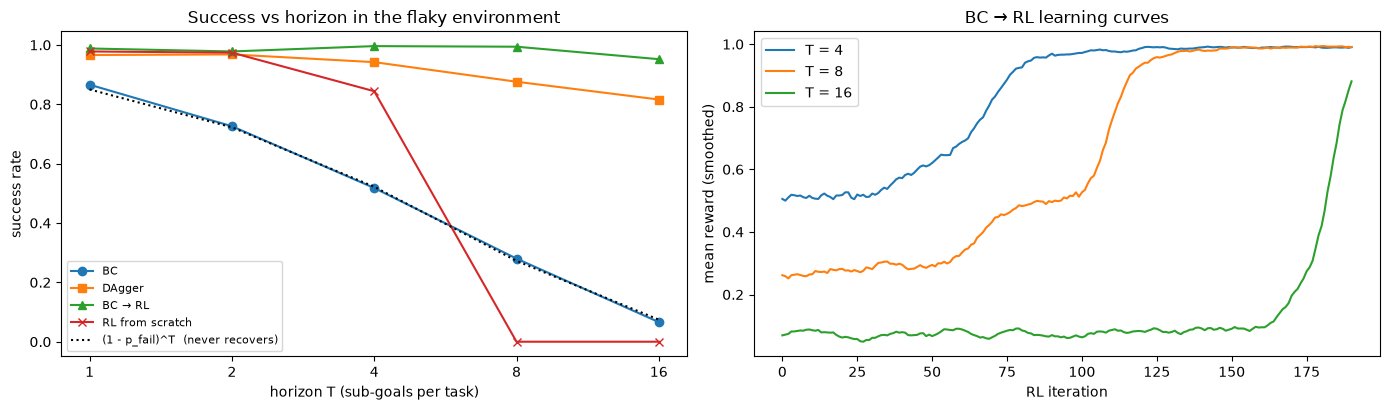

In [3]:
horizons = [1, 2, 4, 8, 16]
results = {k: [] for k in ["BC", "DAgger", "BC → RL", "RL from scratch"]}
labels_used, rl_logs = {}, {}
t0 = time.time()
for T in horizons:
    rng = np.random.default_rng(T)
    X, A = demonstrations(T, 20, rng)
    W_bc = fit_bc(X, A)
    W_dagger, n_labels = dagger(T, rng=rng)
    W_rl, rl_logs[T] = rl_outcome(T, W_bc, rng=rng)
    W_scratch, _ = rl_outcome(T, None, rng=rng)
    for name, W in [("BC", W_bc), ("DAgger", W_dagger), ("BC → RL", W_rl), ("RL from scratch", W_scratch)]:
        results[name].append(success_rate(W, T))
    labels_used[T] = (len(A), n_labels)
print(f"trained {4 * len(horizons)} policies in {time.time() - t0:.0f}s\n")

print(f"{'T':>3} | " + " | ".join(f"{k:>15}" for k in results) + " | (1 - p_fail)^T")
for i, T in enumerate(horizons):
    print(f"{T:>3} | " + " | ".join(f"{results[k][i]:>15.3f}" for k in results) + f" | {0.85 ** T:>14.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for (name, vals), m in zip(results.items(), ["o", "s", "^", "x"]):
    axes[0].plot(horizons, vals, marker=m, label=name)
axes[0].plot(horizons, [0.85 ** T for T in horizons], "k:", label="(1 - p_fail)^T  (never recovers)")
axes[0].set_xscale("log", base=2); axes[0].set_xticks(horizons); axes[0].set_xticklabels(horizons)
axes[0].set_xlabel("horizon T (sub-goals per task)"); axes[0].set_ylabel("success rate")
axes[0].set_title("Success vs horizon in the flaky environment"); axes[0].legend(fontsize=8)
for T in [4, 8, 16]:
    axes[1].plot(np.convolve(rl_logs[T]["reward"], np.ones(10) / 10, "valid"), label=f"T = {T}")
axes[1].set_xlabel("RL iteration"); axes[1].set_ylabel("mean reward (smoothed)")
axes[1].set_title("BC → RL learning curves"); axes[1].legend()
plt.tight_layout(); plt.show()

**Reading the results:**

- **BC tracks $(1 - p_{\text{fail}})^T$.** It succeeds exactly when no tool
  happens to fail, because it never learned to recover. That's the
  compounding-error story in its purest form: one unrecoverable situation per
  step, so failure probability grows with every additional step.
- **DAgger fixes it**: it reaches the states BC never saw, and the expert labels
  them. Its success degrades slowly with $T$, because its policy still
  has to beat the strong happy-path habit, and only a fraction of the new
  labels are error states.
- **BC → RL is the best learner**, and it used **no labels beyond the
  demonstrations**, only a 0/1 outcome. During training it hit tool failures,
  occasionally tried `RETRY` / `FIX_ARGS` (BC gave them a tiny but non-zero
  probability, about 0.1%), and those episodes beat their group's mean.
- **RL from scratch** works for $T \le 4$, then collapses to 0. A uniform
  random policy succeeds with probability about $(1/8)^T$. At $T = 8$ that's
  $6 \times 10^{-8}$, so every group is all zeros and every advantage is 0.
  This is the "RL only sharpens what the model already samples" lesson from
  notebooks 8 and 12, at agent scale.
- **Look at the $T = 16$ learning curve.** The BC start succeeds only about 7% of
  the time, so learning starts slowly, and how soon it takes off depends on
  luck. Section 5.4 repeats it over several seeds.

### 5.3 What each method had to pay for

The success rate is only half the comparison. The other half is the **kind and
amount of supervision**.

In [4]:
print(f"{'T':>3} | {'BC: expert labels':>18} | {'DAgger: expert labels':>22} | {'RL: expert labels':>18} | {'RL: outcome checks':>19}")
for T in horizons:
    n_demo, n_dagger = labels_used[T]
    n_checks = 200 * 16 * 8                                 # iterations x prompts x group size
    print(f"{T:>3} | {n_demo:>18,} | {n_dagger:>22,} | {n_demo:>18,} | {n_checks:>19,}")

  T |  BC: expert labels |  DAgger: expert labels |  RL: expert labels |  RL: outcome checks
  1 |                 20 |                    159 |                 20 |              25,600
  2 |                 40 |                    353 |                 40 |              25,600
  4 |                 80 |                    738 |                 80 |              25,600
  8 |                160 |                  1,397 |                160 |              25,600
 16 |                320 |                  2,813 |                320 |              25,600


RL used **tens of thousands of episodes**, far more interaction than
DAgger. But each one needed only a **cheap, automatic check** of the
outcome. DAgger needed an expert to **label thousands of individual
states visited by an imperfect student**. For a coding agent, that means a
senior engineer annotating every shell command a junior model typed. In
practice it's the most expensive supervision of all, and it scales with $T$.

**That's the trade the field made: spend compute on interaction, save humans
for writing checks.** Unit tests, answer keys and final-state checks are
written once and used millions of times.

### 5.4 Long horizons: zero-variance groups, and the curriculum fix

At $T = 16$, the BC start succeeds about 6% of the time, so in a group of 8 the
chance that **all** attempts fail is $0.94^8 \approx 0.6$. Most groups carry
no signal (notebook 8, Section 4). The `zero_var` log shows it directly.

The standard remedies are the ones from notebooks 9 and 12: a larger group,
DAPO's dynamic sampling, and above all a **curriculum**. Train on short
tasks first; the skill learned there ("when a tool errors, recover") doesn't
depend on the length of the task, so it transfers. Many agentic RL systems use
some form of curriculum: by difficulty, by number of turns, or by the
model's current pass rate (WebRL generates new tasks from failures; several
search-agent recipes filter out prompts the model always or never solves).

8 runs in 55s

success at T = 16 after 200 iterations (4 seeds):
  direct      ['0.99', '0.26', '0.99', '0.23']  mean 0.62
  curriculum  ['0.97', '0.99', '0.98', '0.99']  mean 0.98


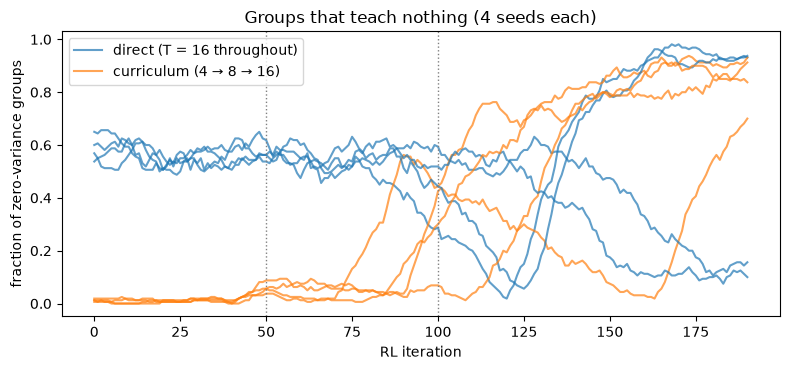

In [5]:
BUDGET = 200                                   # RL iterations, same for both strategies
direct_runs, curr_runs = [], []
t0 = time.time()
for seed in range(4):
    rng = np.random.default_rng(100 + seed)
    X, A = demonstrations(16, 20, rng)
    W_bc16 = fit_bc(X, A)
    # direct: the whole budget at T = 16
    W_direct, log_direct = rl_outcome(16, W_bc16, n_iters=BUDGET, rng=rng)
    # curriculum: 25% at T = 4, 25% at T = 8, 50% at T = 16
    W_c, log_c4 = rl_outcome(4, W_bc16, n_iters=BUDGET // 4, rng=rng)
    W_c, log_c8 = rl_outcome(8, W_c, n_iters=BUDGET // 4, rng=rng)
    W_c, log_c16 = rl_outcome(16, W_c, n_iters=BUDGET // 2, rng=rng)
    direct_runs.append((success_rate(W_direct, 16), log_direct["zero_var"]))
    curr_runs.append((success_rate(W_c, 16), log_c4["zero_var"] + log_c8["zero_var"] + log_c16["zero_var"]))
print(f"8 runs in {time.time() - t0:.0f}s\n")
print("success at T = 16 after", BUDGET, "iterations (4 seeds):")
print("  direct     ", [f"{s:.2f}" for s, _ in direct_runs], f" mean {np.mean([s for s, _ in direct_runs]):.2f}")
print("  curriculum ", [f"{s:.2f}" for s, _ in curr_runs], f" mean {np.mean([s for s, _ in curr_runs]):.2f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 3.8))
sm = lambda v: np.convolve(v, np.ones(10) / 10, "valid")
for i, ((_, zd), (_, zc)) in enumerate(zip(direct_runs, curr_runs)):
    ax.plot(sm(zd), color="C0", alpha=0.7, label="direct (T = 16 throughout)" if i == 0 else None)
    ax.plot(sm(zc), color="C1", alpha=0.7, label="curriculum (4 → 8 → 16)" if i == 0 else None)
for x in [BUDGET // 4, BUDGET // 2]:
    ax.axvline(x, color="gray", ls=":", lw=1)
ax.set_xlabel("RL iteration"); ax.set_ylabel("fraction of zero-variance groups")
ax.set_title("Groups that teach nothing (4 seeds each)"); ax.legend()
plt.tight_layout(); plt.show()

The direct runs spend their early iterations on all-fail groups. Whether and
when they escape is a matter of luck: a run takes off only after a few lucky
recoveries. The curriculum learns recovery on short tasks, where successes
are common and groups are informative, then carries that skill to $T = 16$.
It reaches high success reliably **for the same budget**. In large-scale
agentic RL, where one rollout can take minutes, *reliably* matters as much as
*eventually*.

This is exactly why practical agentic RL looks like this:

1. **Pretraining + instruction/tool SFT** puts the right behaviors *somewhere*
   in the policy's distribution (the prior).
2. **RL** sharpens those behaviors, and learns recovery, on the agent's
   own state distribution.
3. **Curricula, filtering and dynamic sampling** keep the groups informative.

## 6. Anatomy of a real agent trajectory (a preview of notebook 14)

In an LLM, actions and observations are all **tokens in one sequence**. Here is
a two-turn calculator episode, written the way it sits in the context window.
The mask column shows which tokens the loss is allowed to touch.

In [6]:
trajectory = [
    ("prompt",      "user: What is 4831 * 27 - 1999?"),
    ("agent",       "<think>Big multiplication; use the tool.</think> <tool_call>calc(4831*27)</tool_call>"),
    ("observation", "<tool_response>130437</tool_response>"),
    ("agent",       "<tool_call>calc(130437-1999)</tool_call>"),
    ("observation", "<tool_response>128438</tool_response>"),
    ("agent",       "<answer>128438</answer>"),
]
total = {"prompt": 0, "agent": 0, "observation": 0}
print(f"{'segment':<12} {'mask':>4}  text")
for role, text in trajectory:
    n_tok = len(text.split())                       # a crude stand-in for a tokenizer
    total[role] += n_tok
    print(f"{role:<12} {int(role == 'agent'):>4}  {text}")
n_all = sum(total.values())
print("\nshare of the sequence: " + ", ".join(f"{k} {v / n_all:.0%}" for k, v in total.items()))
print("the policy gradient (and the KL penalty) is computed on the 'agent' rows only")

segment      mask  text
prompt          0  user: What is 4831 * 27 - 1999?
agent           1  <think>Big multiplication; use the tool.</think> <tool_call>calc(4831*27)</tool_call>
observation     0  <tool_response>130437</tool_response>
agent           1  <tool_call>calc(130437-1999)</tool_call>
observation     0  <tool_response>128438</tool_response>
agent           1  <answer>128438</answer>

share of the sequence: prompt 44%, agent 44%, observation 11%
the policy gradient (and the KL penalty) is computed on the 'agent' rows only


Even in this tiny example, more than half of the sequence (prompt plus tool
results) wasn't written by the policy. Here the tool outputs are just numbers.
In real search or coding agents, tool outputs (web pages, file contents, test
logs) are often **most** of the context. If
they're left in the loss, the policy is trained to *predict web pages*, weighted
by whether the episode succeeded. That's noise in the best case and, as
notebook 14 shows, it slows learning down.

## 7. Key takeaways & FAQ

**The one-paragraph summary.** An agent is an LLM policy in a loop with an
environment. Its training problem is a POMDP whose state is the context
window. Imitation (SFT on expert trajectories) teaches the format cheaply, but
it trains on the expert's states, not the agent's: errors compound and recovery
is never learned. RL from an outcome reward trains on the agent's own states,
learns recovery, needs only a cheap check of success, and can exceed the
teacher. But it can only sharpen behaviors the starting policy already
samples, so it starts from an SFT/instruct model and benefits from curricula.
Mathematically, nothing new is needed: the policy gradient of a multi-turn
trajectory is the sum over the **agent's** tokens, so environment tokens are
masked out.

**Q1. If RL is so good, why does anyone still do SFT on agent trajectories?**
Because RL needs a starting policy that sometimes succeeds (Section 5.4). SFT
is the cheapest way to get the *format* (valid tool-call JSON, the ReAct
pattern) and a non-zero success rate. The standard recipe is **SFT (cold start)
→ RL**, just like DeepSeek-R1's cold-start stage (notebook 9). Some
works skip SFT when the instruct model already calls tools well enough.

**Q2. Isn't DAgger "RL"?** No. DAgger is *interactive imitation learning*. It
collects data on-policy (like RL), but the training signal is still an expert's
action label at every state (like BC). It shares RL's fix for distribution shift
but not RL's cheap supervision. For LLM agents, DAgger-style ideas survive as
**on-policy distillation**: a strong teacher model scores or corrects the
student's own trajectories.

**Q3. Prompting methods like ReAct and Reflexion need no training. When are they enough?**
When the base model is already strong at the task and the horizon is short.
They're a good baseline, and the ReAct format is what RL then optimizes.
Reflexion-style memory improves *one* episode's retries at inference time.
RL improves the *weights*, so every future episode benefits.

**Q4. What does the toy leave out?**
Real agents have huge, structured action spaces (arbitrary text), partial
observability (the toy's state was fully visible), very long contexts, and
expensive, slow environments. Notebooks 14–17 add these back one at a time:
token-level policies and masking (14), credit assignment over turns (15), a
real model and real tools (16), and infrastructure and reward hacking at scale
(17).

**Exercises.**

1. Set `p_fail = 0` in the evaluation. Does BC become optimal? What does that
   say about *when* imitation is enough?
2. Give DAgger the same number of *episodes* as RL. How many expert labels
   would that cost at $T = 16$?
3. Remove the bias feature and the sub-goal features from the error states
   (so BC's untrained error weights give a *uniform* policy there). How does
   RL's speed change, and why? (Hint: the probability of trying `RETRY`.)
4. Add a step cost of $-0.01$ per action to the reward. Does the RL policy
   change? Could it ever prefer *not* to recover?